# LAB 01 — Solution de référence


In [5]:
# !pip install pandas
# !pip install matplotlib

In [8]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Résolution robuste : fonctionne quel que soit le dossier de lancement
CANDIDATES = [
    Path("../data/deliveries_lab.json"),
    Path("data/deliveries_lab.json"),
    Path("LAB_01_JSON_JUPYTER_PANDAS/data/deliveries_lab.json"),
]
DATA_PATH = next(p for p in CANDIDATES if p.exists())

df = pd.read_json(DATA_PATH)
df.head()


,delivery_id,customer_id,customer_city,vehicle_type,distance_km,traffic_level,weather,delivery_minutes,late_delivery
0,1001,501,Paris,bike,4.2,high,rain,38,1
1,1002,502,Poissy,car,18.4,medium,clear,42,0
2,1003,503,PARIS,bike,3.1,low,clear,19,0
3,1004,501,Paris,scooter,7.8,high,rain,47,1
4,1005,504,Versailles,car,15.0,medium,clear,34,0


In [9]:
print(df.shape)
print(df.columns.tolist())
df.info()


(13, 9)
['delivery_id', 'customer_id', 'customer_city', 'vehicle_type', 'distance_km', 'traffic_level', 'weather', 'delivery_minutes', 'late_delivery']
<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   delivery_id       13 non-null     int64  
 1   customer_id       13 non-null     int64  
 2   customer_city     13 non-null     str    
 3   vehicle_type      13 non-null     str    
 4   distance_km       12 non-null     float64
 5   traffic_level     12 non-null     str    
 6   weather           13 non-null     str    
 7   delivery_minutes  13 non-null     int64  
 8   late_delivery     13 non-null     int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 1.0 KB


In [10]:
print(df.isna().sum())
print("Doublons:", df.duplicated().sum())


delivery_id         0
customer_id         0
customer_city       0
vehicle_type        0
distance_km         1
traffic_level       1
weather             0
delivery_minutes    0
late_delivery       0
dtype: int64
Doublons: 1


In [11]:
df["customer_city"] = (
    df["customer_city"]
    .astype("string")
    .str.strip()
    .str.lower()
)
df["customer_city"].value_counts(dropna=False)


customer_city
paris                   6
poissy                  2
versailles              2
nanterre                2
boulogne-billancourt    1
Name: count, dtype: Int64

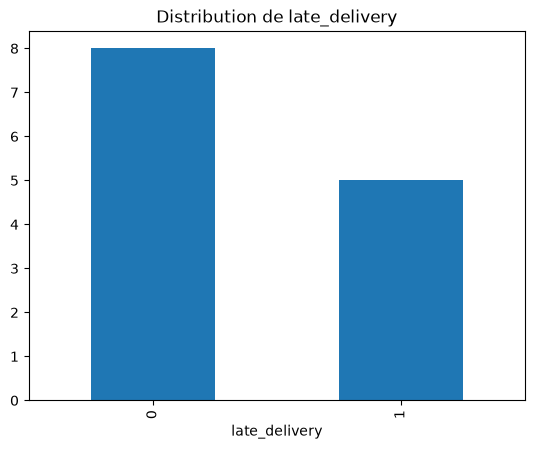

In [12]:
df["late_delivery"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution de late_delivery")
plt.show()


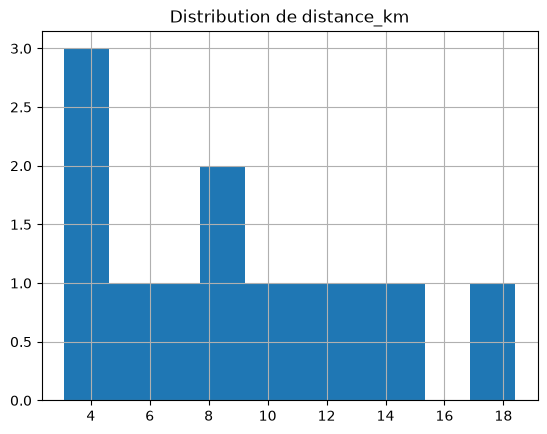

In [13]:
df["distance_km"].hist()
plt.title("Distribution de distance_km")
plt.show()
